In [2]:
import torch
from src.model import TransformDecoder, ImageTransformPredictor
from src.dataset import ImageTransformer, TransformTokenizer
from src.dataset import DomainNetDataset, get_domainnet_dataloaders
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms

%load_ext autoreload
%autoreload 2

In [5]:
# /home/jovyan/.mlspace/envs/genimages

### Testing Model

In [26]:
config = OmegaConf.load('configs/train_config_006.yaml')

preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

In [27]:
model = ImageTransformPredictor(config.model)

Loaded pretrained weights for efficientnet-b3


In [28]:
checkpoint_path = 'checkpoints/itp_006/checkpoint_epoch_21.pth' # хороший чекпоинт в 008
# checkpoint_path = 'checkpoints/itp_009/checkpoint_epoch_20.pth'

checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

ready


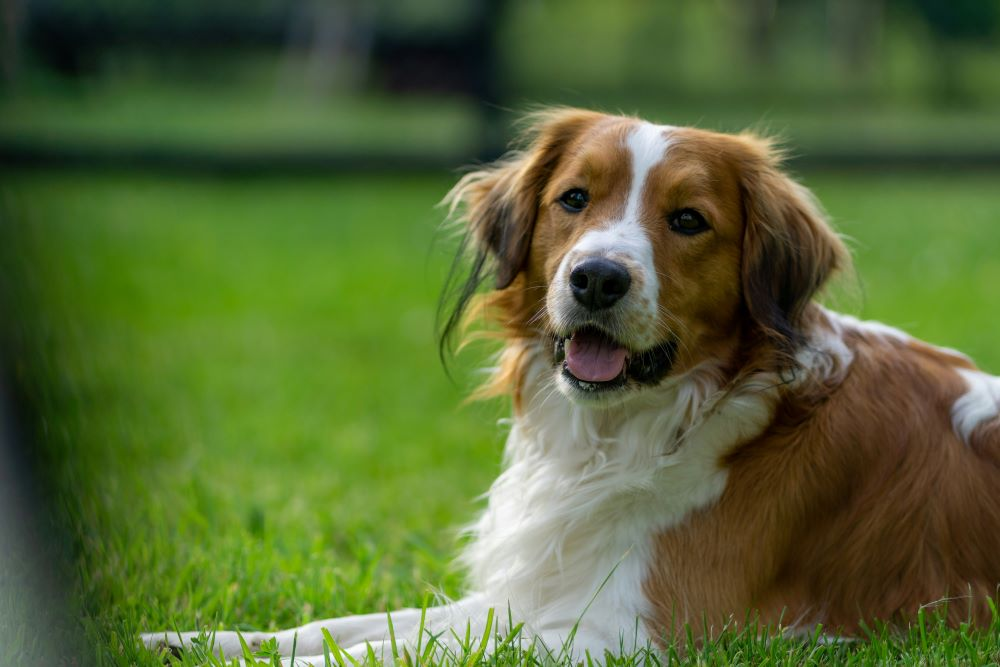

In [23]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)
image_1

['rotate_180', 'jpeg_artefacts', 'vertical_flip']


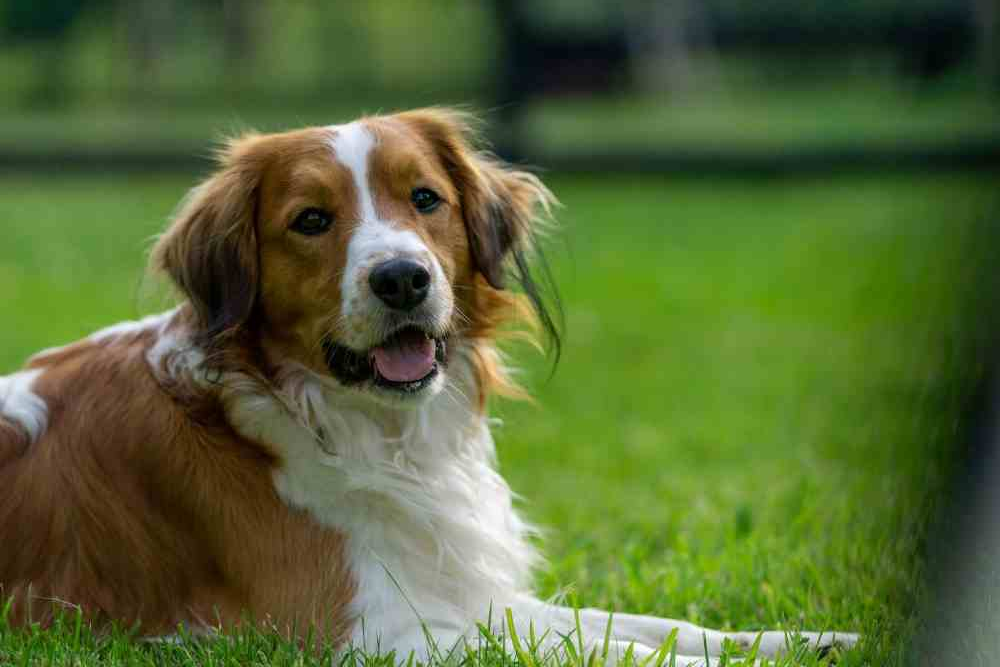

In [34]:
image_path_1 = 'assets/image.jpg'
image_path_2 = 'assets/dog.jpg'

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, 0.5)
print(sequence_1)
transformed_image_1

In [35]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=False)
# generated = model.generate(image_tensor_1, transformed_image_tensor, max_new_tokens=10, do_sample=True, top_k=3)

tokenizer = TransformTokenizer()
tokens = tokenizer.decode(generated[0], skip_special_tokens=True)
print(f"Predicted: {tokens}")
print(f"Target: {sequence_1}")

Predicted: ['horizontal_flip']
Target: ['rotate_180', 'jpeg_artefacts', 'vertical_flip']


### ViT Encoder

In [3]:
from src.model import ViTImageEncoder, ImagePairEncoderViT

In [7]:
config = OmegaConf.load('configs/train_config_vit.yaml')

model = ImagePairEncoderViT(config.model.encoder)
preprocess = model.preprocess

In [10]:
image_path = 'assets/image.jpg'

image = Image.open(image_path)
image_tensor = preprocess(image).unsqueeze(0)
model(image_tensor, image_tensor).shape

torch.Size([1, 395, 512])

In [21]:
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
vit = vit_b_16(weights=weights)
vit.heads = nn.Identity()

---
---

### Image Preprocess

In [3]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torchvision import transforms
from PIL import Image

weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()


image_path = 'assets/image.jpg'

image = Image.open(image_path)
image_tensor = preprocess_transform(image).shape

По сути у ViT тут:
```
transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BILINEAR),  # Изменение размера до 256x256
    transforms.CenterCrop(224),  # Центральный кроп до 224x224
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])
```

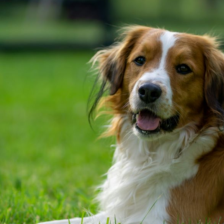

In [ ]:
from PIL import Image
from torchvision.transforms.functional import to_pil_image
import torch
from torchvision.models import ViT_B_16_Weights


weights = ViT_B_16_Weights.IMAGENET1K_V1
preprocess_transform = weights.transforms()

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = preprocess_transform(image)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

pil_image = to_pil_image(denorm_tensor)
pil_image

In [10]:
from torchvision.models import EfficientNet_B3_Weights

weights = EfficientNet_B3_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

У EfficientNet-B3 аналогично оригинальные размеры 300.
```
transform = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC),  # Изменение размера до 320x320 с бикубической интерполяцией
    transforms.CenterCrop(300),  # Центральный кроп до 300x300
    transforms.ToTensor(),  # Преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # Нормализация
])
```
- EfficientNet поддерживает произвольные размеры благодаря AdaptiveAvgPool2d.
- Это не "динамический препроцессинг" как в Qwen-VL, а гибкая CNN-архитектура.
- Но предобученные веса оптимальны только для native resolution.
- Для максимальной точности: ресайз до native size модели (лучше с паддингом, если не хотите кропа).

In [ ]:
from efficientnet_pytorch import EfficientNet

model_name = 'efficientnet-b3'
image_size = EfficientNet.get_image_size(model_name)
image_size

300

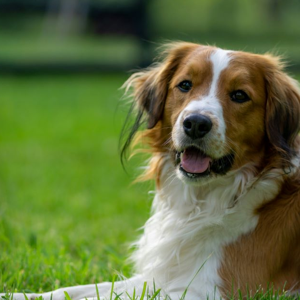

In [ ]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch


transform = transforms.Compose([
    transforms.Resize(320, interpolation=InterpolationMode.BICUBIC), # меньшую сторону до 320
    transforms.CenterCrop(300),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

# Денормализация
mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

# Преобразование в PIL
pil_image = to_pil_image(denorm_tensor)
pil_image

У нас же в EffNet:

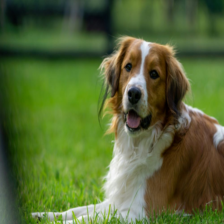

In [17]:
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torch


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

image_path = 'assets/image.jpg'
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)

denorm_tensor = image_tensor * std + mean
denorm_tensor = torch.clamp(denorm_tensor, 0, 1)

pil_image = to_pil_image(denorm_tensor)
pil_image